# Imports

In [1]:
import math
import os
import sys
import torch

from utils.checkpoint import load_checkpoint, save_checkpoint
from utils.data import get_dataloaders, get_img_from_loader

sys.path.append("..")

from models.lenet import Net as LeNet
from config import Config


In [2]:
config = Config()
device = config.device

# Prepare data
_, val_loader, test_loader = get_dataloaders(
    data_dir="../data",
    batch_size=config.test_batch_size,
    num_workers=config.num_workers,
    use_cuda=torch.cuda.is_available(),
)

# Model
lenet_model = LeNet(
    prior_sigma1=math.exp(0),
    prior_sigma2=math.exp(-6),
    prior_pi=0.5,
    num_classes=10,
).to(device)

# Optimizer (needed to load checkpoint)
optimizer = torch.optim.Adam(lenet_model.parameters(), lr=config.learning_rate)
# Load weights
# config.model_name = 'mnist_bayesian_lenet'
config.model_name = 'lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1'
epoch = load_checkpoint(lenet_model, optimizer, f'{config.checkpoint_path}/{config.model_name}/{config.get_checkpoint_name(190, date="20260129")}', device)
# load_checkpoint(lenet_model, optimizer, f'{config.checkpoint_path}/{config.get_checkpoint_name(475, date="20251201")}', device)


[checkpoint] Loaded from ../checkpoints/lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1/lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1_epoch_190_20260129.pth, starting at epoch 191


# Evaluate

In [3]:
from train import test

loss, accuracy = test(lenet_model, test_loader, device, epoch)
print(f"Loss: {loss:.6f}, Accuracy: {accuracy:.4f}")

Test: loss=0.039209, acc=98.87%
Loss: 0.039209, Accuracy: 0.9887



Expected Calibration Error: 0.0020


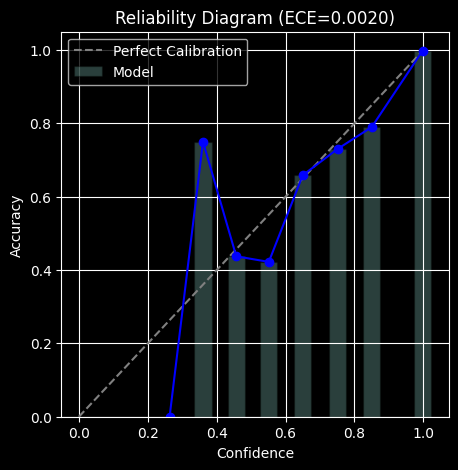

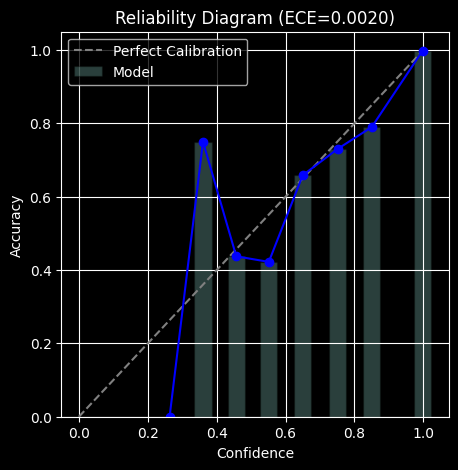

In [4]:
from utils.calibration import reliability_diagram
reliability_diagram(lenet_model, test_loader, device, T=20)

In [5]:
from evaluate import evaluate_with_uncertainty

evaluate_with_uncertainty(lenet_model, test_loader, device, mc_samples=20)

Total Uncertainty (mean): 0.015869930386543274
Aleatoric (mean): 0.014636479318141937
Epistemic (mean): 0.001233452232554555


(tensor([7, 2, 1,  ..., 4, 5, 6]),
 (tensor([1.2224e-04, 1.5145e-05, 1.9735e-04,  ..., 1.1758e-05, 4.8814e-04,
          4.9062e-05]),
  tensor([1.2224e-04, 1.5145e-05, 1.9735e-04,  ..., 1.1758e-05, 4.8810e-04,
          4.9062e-05]),
  tensor([1.1529e-09, 6.0645e-12, 4.4367e-09,  ..., 8.5611e-12, 3.5227e-08,
          1.2398e-10])))

# Images

In [24]:
def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    """
    Add salt and pepper noise to an image
    Args:
        image: torch tensor of shape (1, 28, 28) for MNIST
        salt_prob: probability of salt noise (white pixels)
        pepper_prob: probability of pepper noise (black pixels)
    """
    noisy_image = image.clone()

    # Create random mask for salt noise
    salt_mask = torch.rand_like(image) < salt_prob
    # Create random mask for pepper noise
    pepper_mask = torch.rand_like(image) < pepper_prob

    # Apply salt noise (set to 1)
    noisy_image[salt_mask] = 1.0
    # Apply pepper noise (set to 0)
    noisy_image[pepper_mask] = 0.0

    return noisy_image

def add_salt_pepper_noise_normalized(image, salt_prob=0.05, pepper_prob=0.05, data_mean=0.1307, data_std=0.3081):
    """
    Add salt and pepper noise to a NORMALIZED MNIST image
    """
    noisy_image = image.clone()

    # Calculate normalized values for min (0) and max (1)
    normalized_min = (0.0 - data_mean) / data_std  # ≈ -0.424
    normalized_max = (1.0 - data_mean) / data_std  # ≈ 2.823

    # Create random masks
    salt_mask = torch.rand_like(image) < salt_prob
    pepper_mask = torch.rand_like(image) < pepper_prob

    # Apply salt noise (set to normalized max)
    noisy_image[salt_mask] = normalized_max
    # Apply pepper noise (set to normalized min)
    noisy_image[pepper_mask] = normalized_min

    return noisy_image

In [25]:
from matplotlib import pyplot as plt
from itertools import islice, accumulate
from utils.uncertainty import mc_predict, quantify_uncertainties


def display_images_with_uncertainty(model, test_loader, batch_idx=0, img_idx=0, salt_prob=0.05, pepper_prob=0.05, T=5):
    # Get the i-th batch using islice
    data, target = next(islice(test_loader, batch_idx, batch_idx+1))
    data, target = data.to(device), target.to(device)
    mc_preds = mc_predict(model, data, T)
    output, uncertainties = quantify_uncertainties(mc_preds)

    # Get first image from batch
    img = data[img_idx]
    print(f"Original image shape: {img.shape}")

    # Add salt and pepper noise to the image
    noisy_img = add_salt_pepper_noise_normalized(img, salt_prob=salt_prob, pepper_prob=pepper_prob)

    # Create subplots to compare original and noisy images
    fig, ax = plt.subplots(figsize=(10, 4))

    # Plot original image
    ax.imshow(img.squeeze().cpu().numpy(), cmap='gray')
    ax.set_title(f'Original\nLabel: {target[img_idx].item()}')
    ax.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Total uncertainty: {uncertainties[0].diagonal(dim1=1, dim2=2).sum(-1)[img_idx]}")
    print(f"Aleatoric uncertainty: {uncertainties[1].diagonal(dim1=1, dim2=2).sum(-1)[img_idx]}")
    print(f"Epistemic uncertainty: {uncertainties[2].diagonal(dim1=1, dim2=2).sum(-1)[img_idx]}")


Original image shape: torch.Size([1, 28, 28])


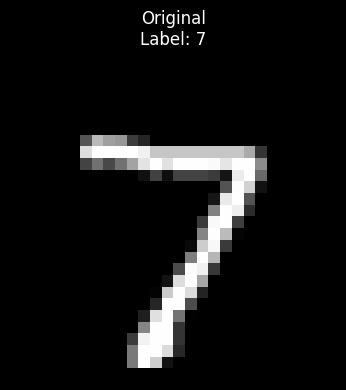

Total uncertainty: 0.00013979805225972086
Aleatoric uncertainty: 0.00013979690265841782
Epistemic uncertainty: 1.1449657888462639e-09


In [26]:
# Цифра 3
display_images_with_uncertainty(lenet_model, test_loader, batch_idx=0, img_idx=0, salt_prob=0.1, pepper_prob=0.5, T=15)

Original image shape: torch.Size([1, 28, 28])


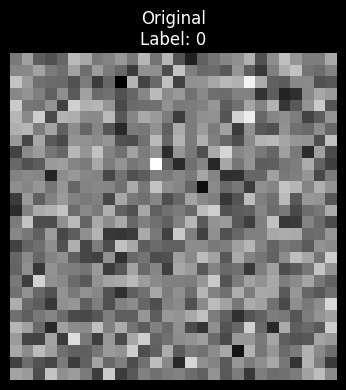

Total uncertainty: 0.25118160247802734
Aleatoric uncertainty: 0.2363976389169693
Epistemic uncertainty: 0.014783955179154873


In [27]:
from torch.utils.data import TensorDataset, DataLoader

# Shape: [Batch, Channels, Height, Width]
noise_image = torch.randn(1, 1, 28, 28)
label = torch.tensor([0])
noise_image = noise_image.to(device)
# Wrap in a dataset (expects a tuple if you have labels, or just the image)
dataset = TensorDataset(noise_image, label)

# Create the DataLoader
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
display_images_with_uncertainty(lenet_model, dataloader, batch_idx=0, img_idx=0, salt_prob=0.1, pepper_prob=0.5, T=15)


# Corruptions

In [3]:
from utils.corruptions import gaussian_blur, test_on_corruptions
from utils.data import get_img_from_loader

In [4]:
corruptions = {
    'Original': lambda x: x,
    'WeakBlur': lambda x: gaussian_blur(x, kernel_size=3),
    'Default Blur': lambda x: gaussian_blur(x, kernel_size=5),
    'StrongBlur': lambda x: gaussian_blur(x, kernel_size=7),
    'VeryStrongBlur': lambda x: gaussian_blur(x, kernel_size=9),
}

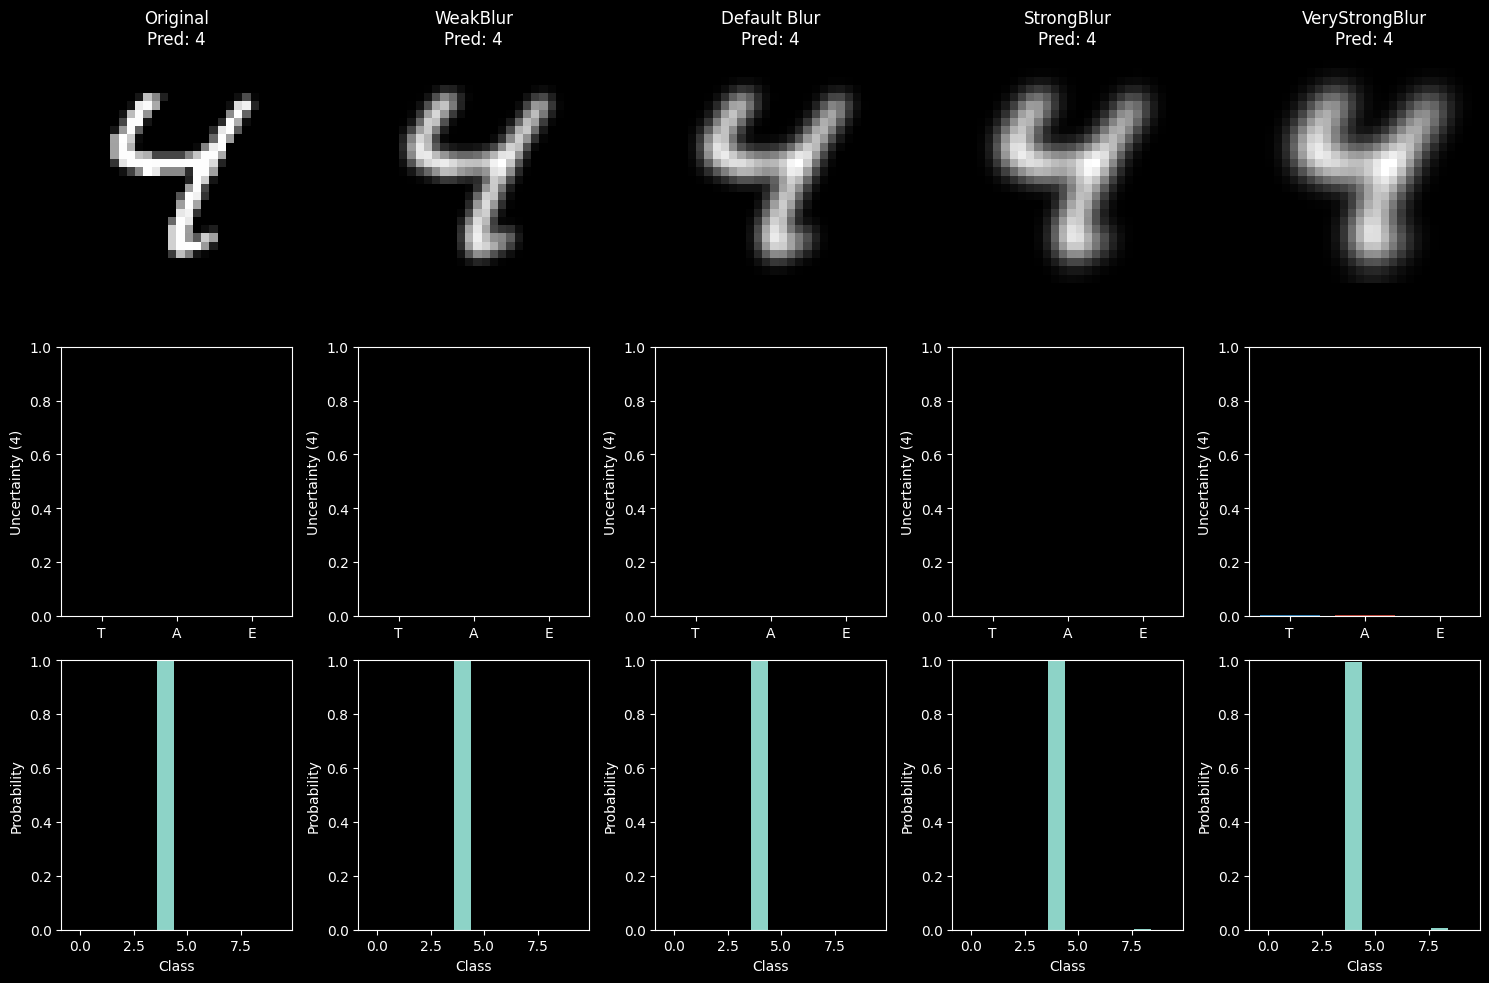

In [5]:
img, label = get_img_from_loader(test_loader, batch_idx=0, img_idx=6, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label,), T=10)

Random batch index: 285, image index: 7


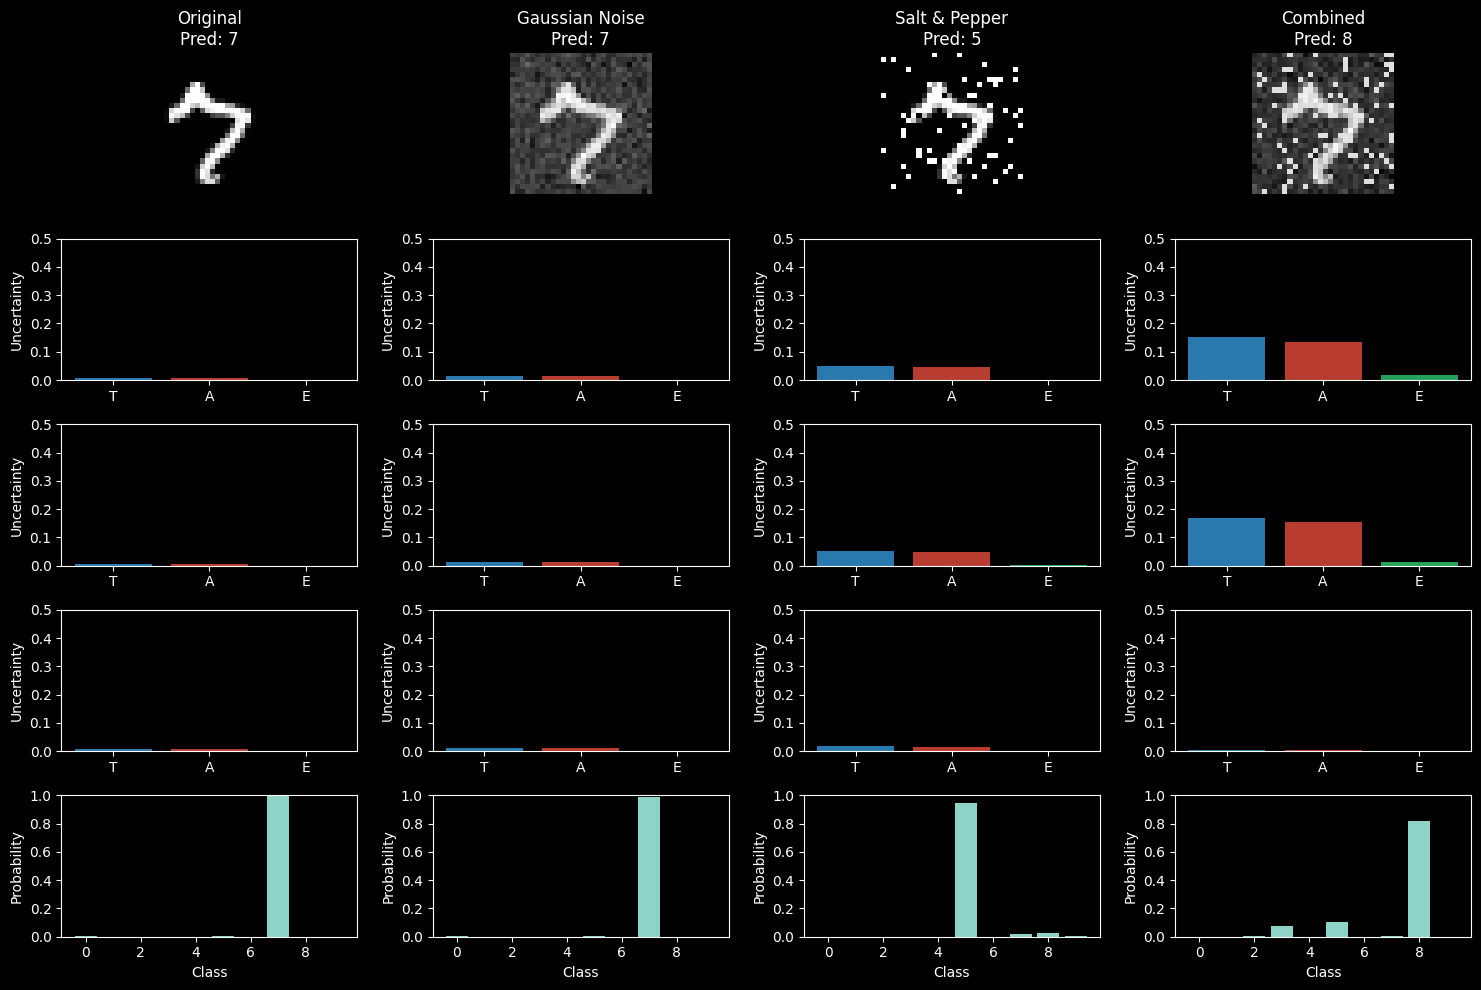

In [22]:
rand_batch_idx = random.randint(0, len(test_loader)-1)
rand_img_idx = random.randint(0, config.test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
test_on_corruptions(lenet_model, test_loader, device, batch_idx=rand_batch_idx, img_idx=rand_img_idx)

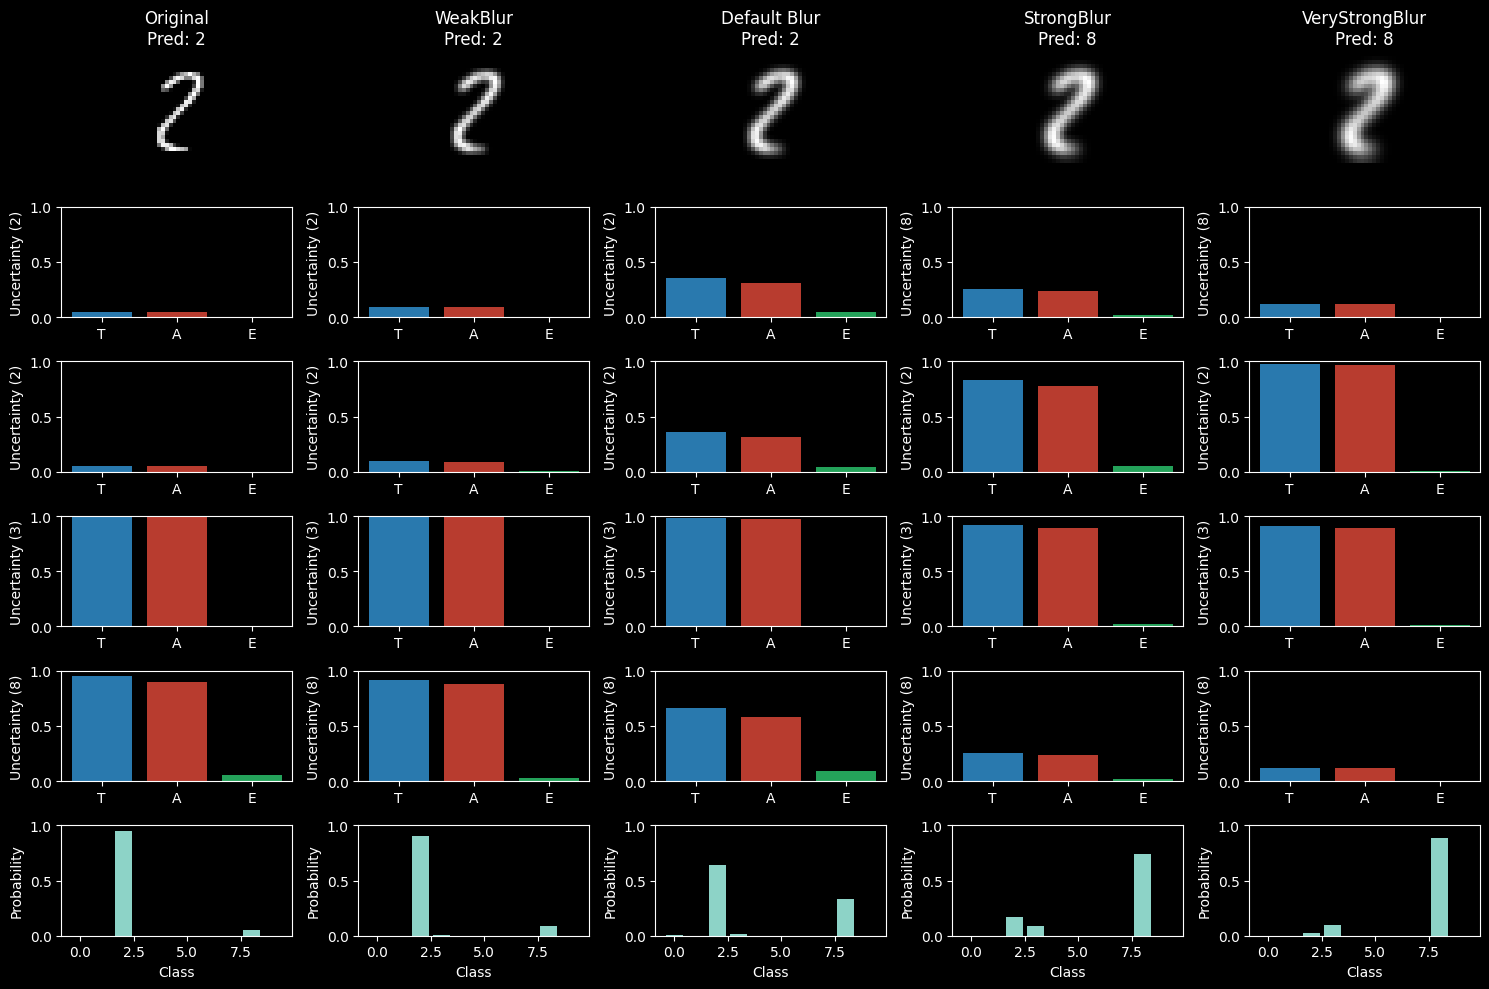

In [68]:
test_on_corruptions(lenet_model, test_loader, device, T=10, batch_idx=43, img_idx=11)

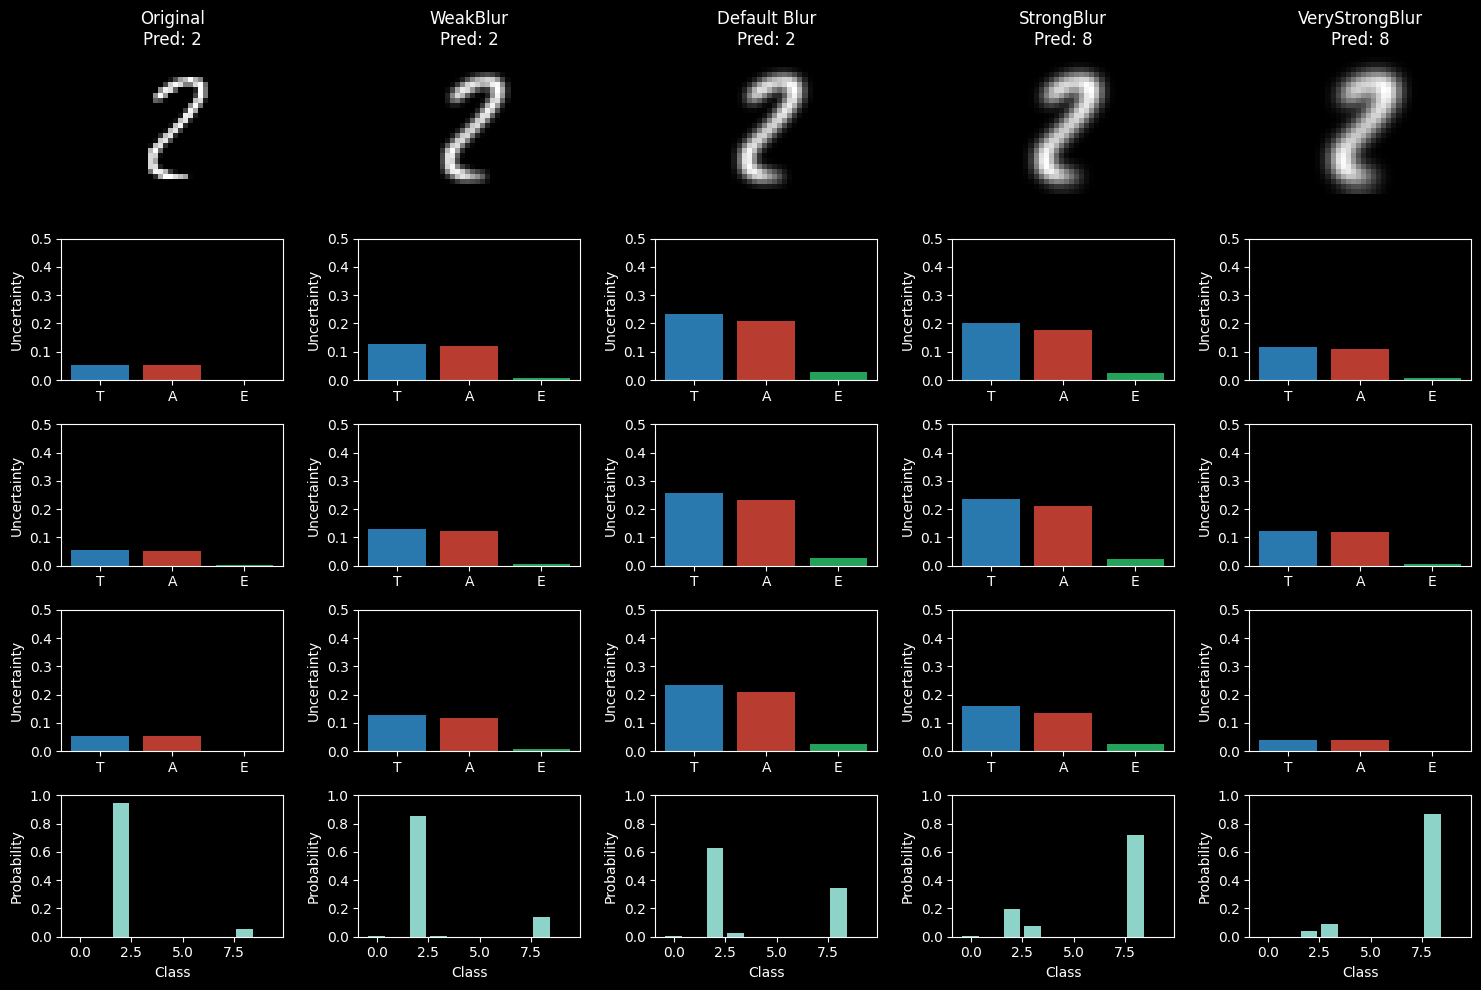

In [32]:
test_on_corruptions(lenet_model, test_loader, device, T=10, batch_idx=43, img_idx=11)

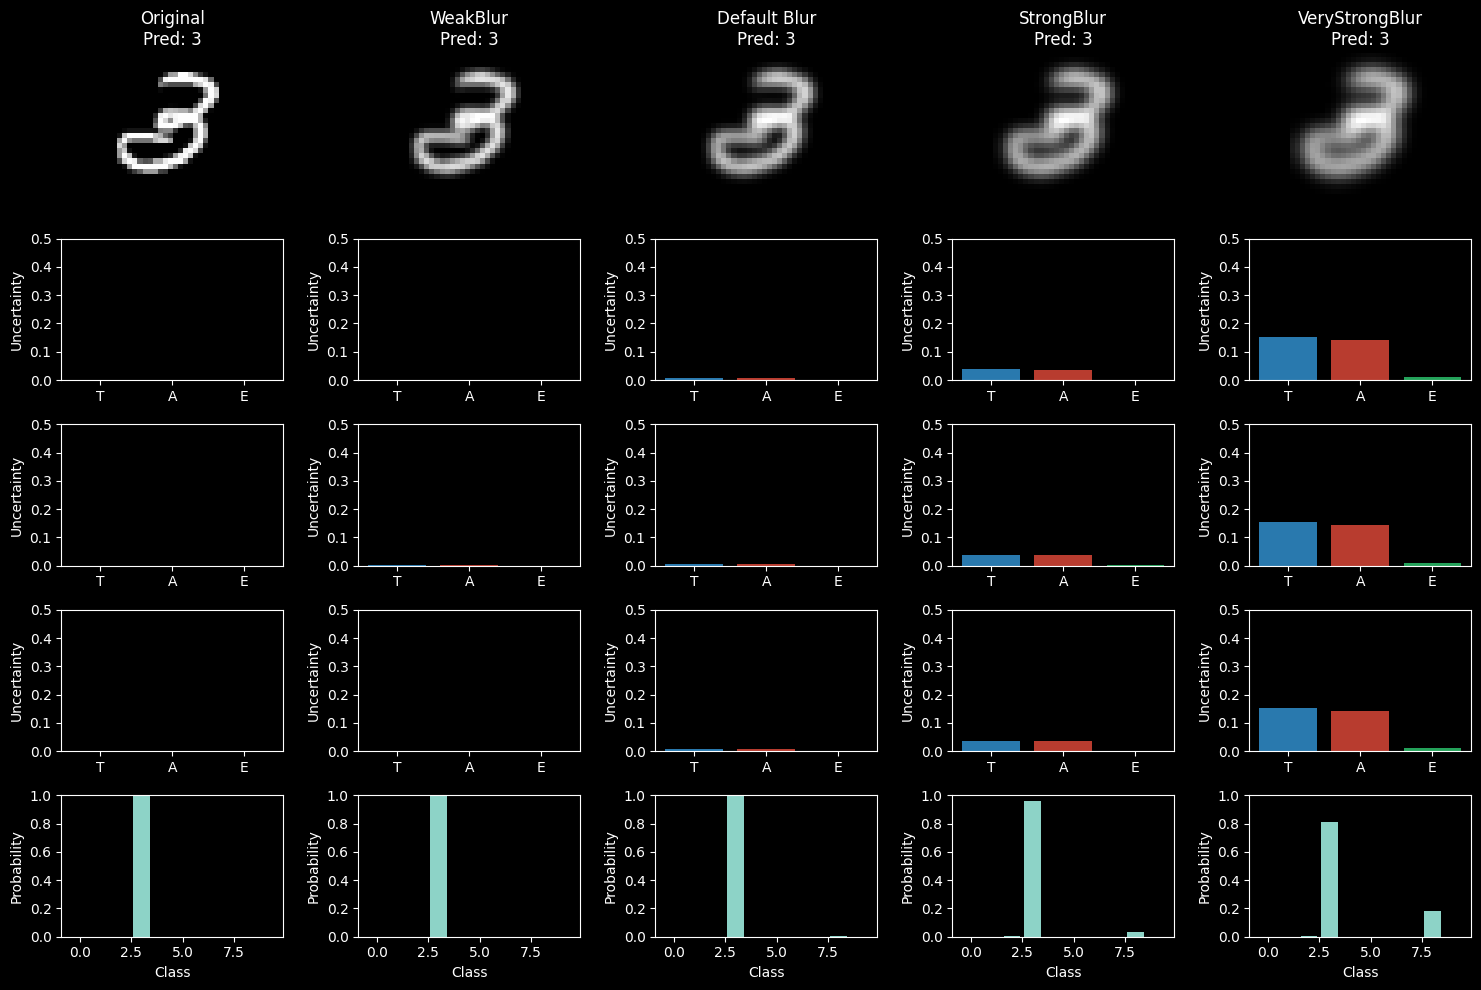

In [23]:
test_on_corruptions(lenet_model, test_loader, device, T=10, batch_idx=695, img_idx=12)

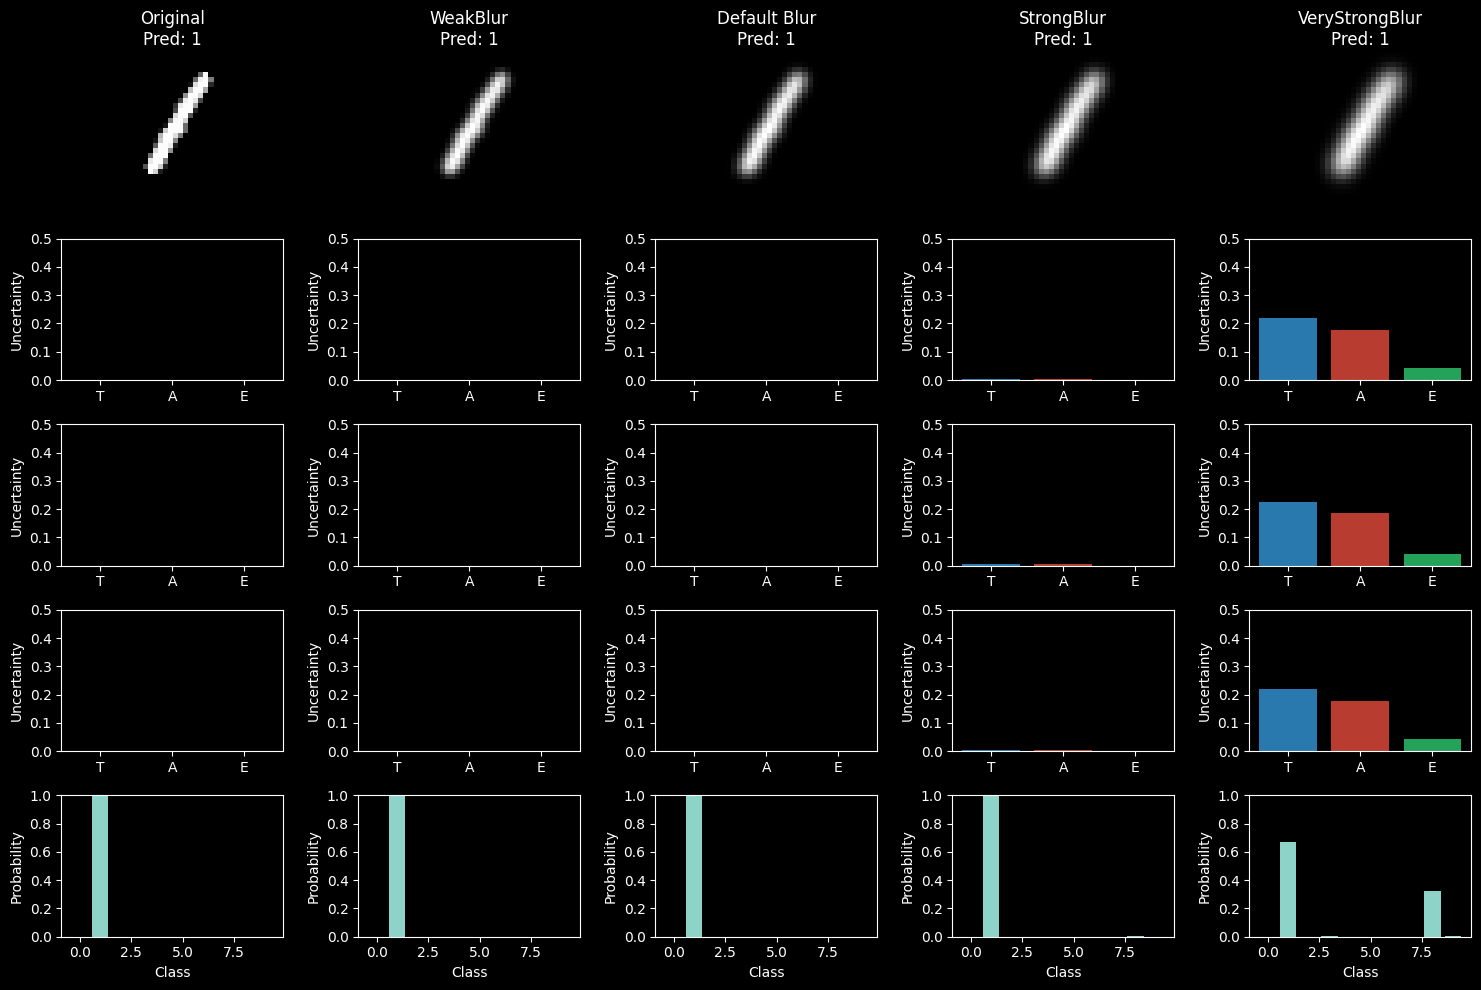

In [24]:
test_on_corruptions(lenet_model, test_loader, device, T=10, batch_idx=130, img_idx=0)

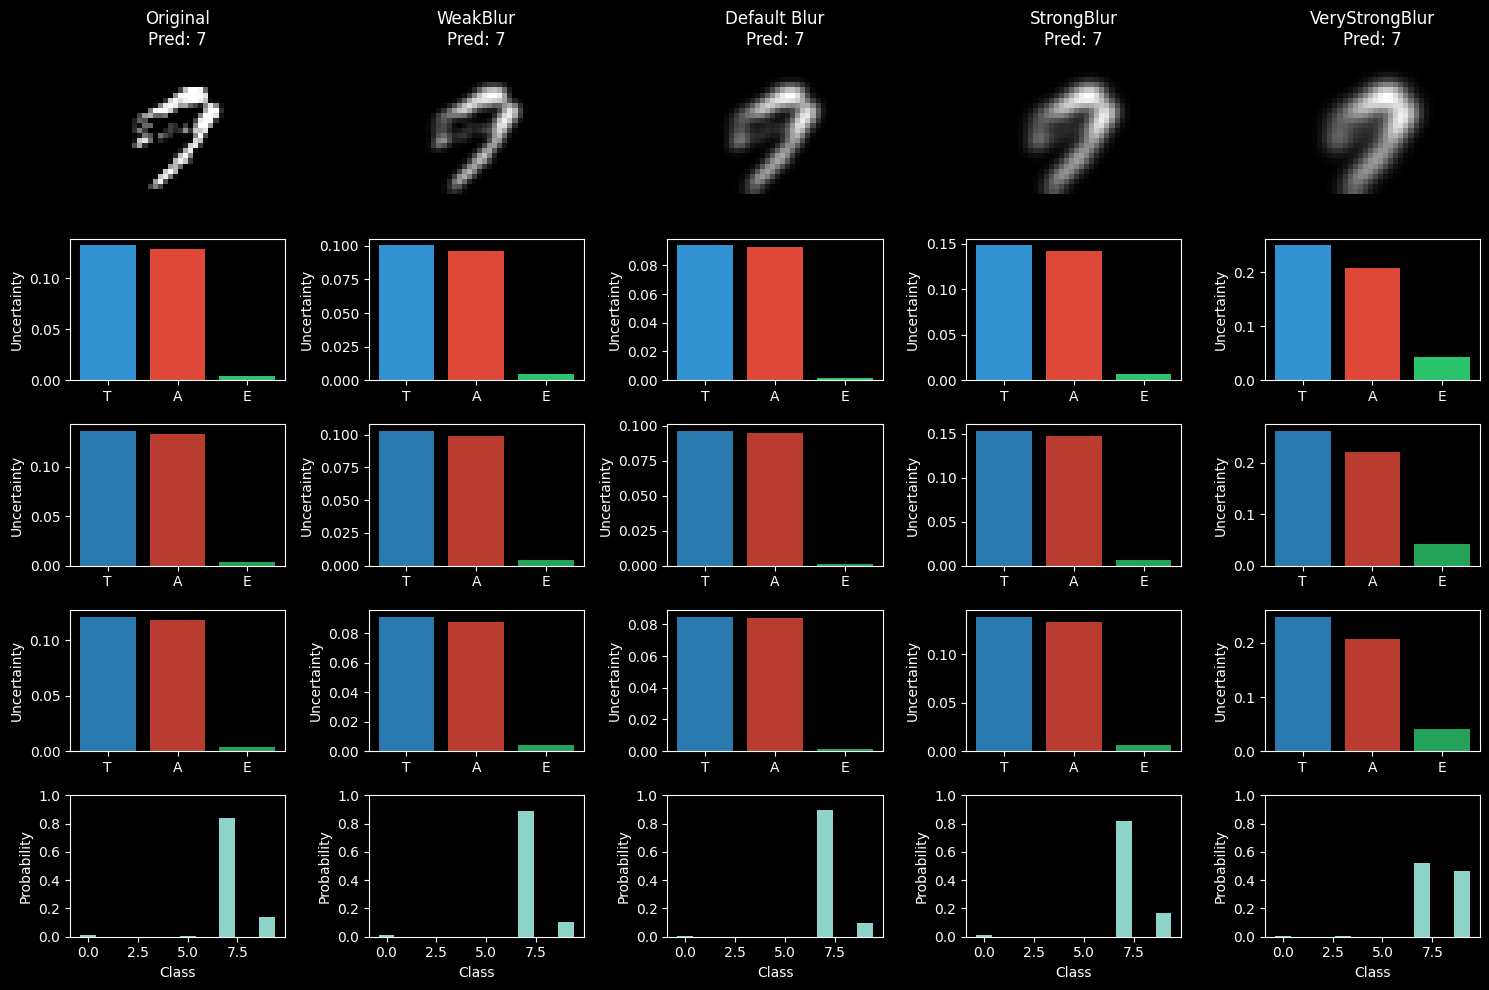

In [28]:
test_on_corruptions(lenet_model, test_loader, device, T=15, batch_idx=688, img_idx=10)

## Salt & Pepper

In [73]:
corruptions = {
    'Original': lambda x: x,
    'Weak Salt': lambda x: add_salt_pepper(x, 0.01, 0.01),
    'Default Salt': lambda x: add_salt_pepper(x, 0.03, 0.01),
    'Strong Salt': lambda x: add_salt_pepper(x, 0.05, 0.01),
    'Very Strong Salt': lambda x: add_salt_pepper(x, 0.07, 0.01),
    'Weak Pepper': lambda x: add_salt_pepper(x, 0.01, 0.01),
    'Default Pepper': lambda x: add_salt_pepper(x, 0.01, 0.07),
    'Strong Pepper': lambda x: add_salt_pepper(x, 0.01, 0.12),
    'Very Strong Pepper': lambda x: add_salt_pepper(x, 0.01, 0.2),
}

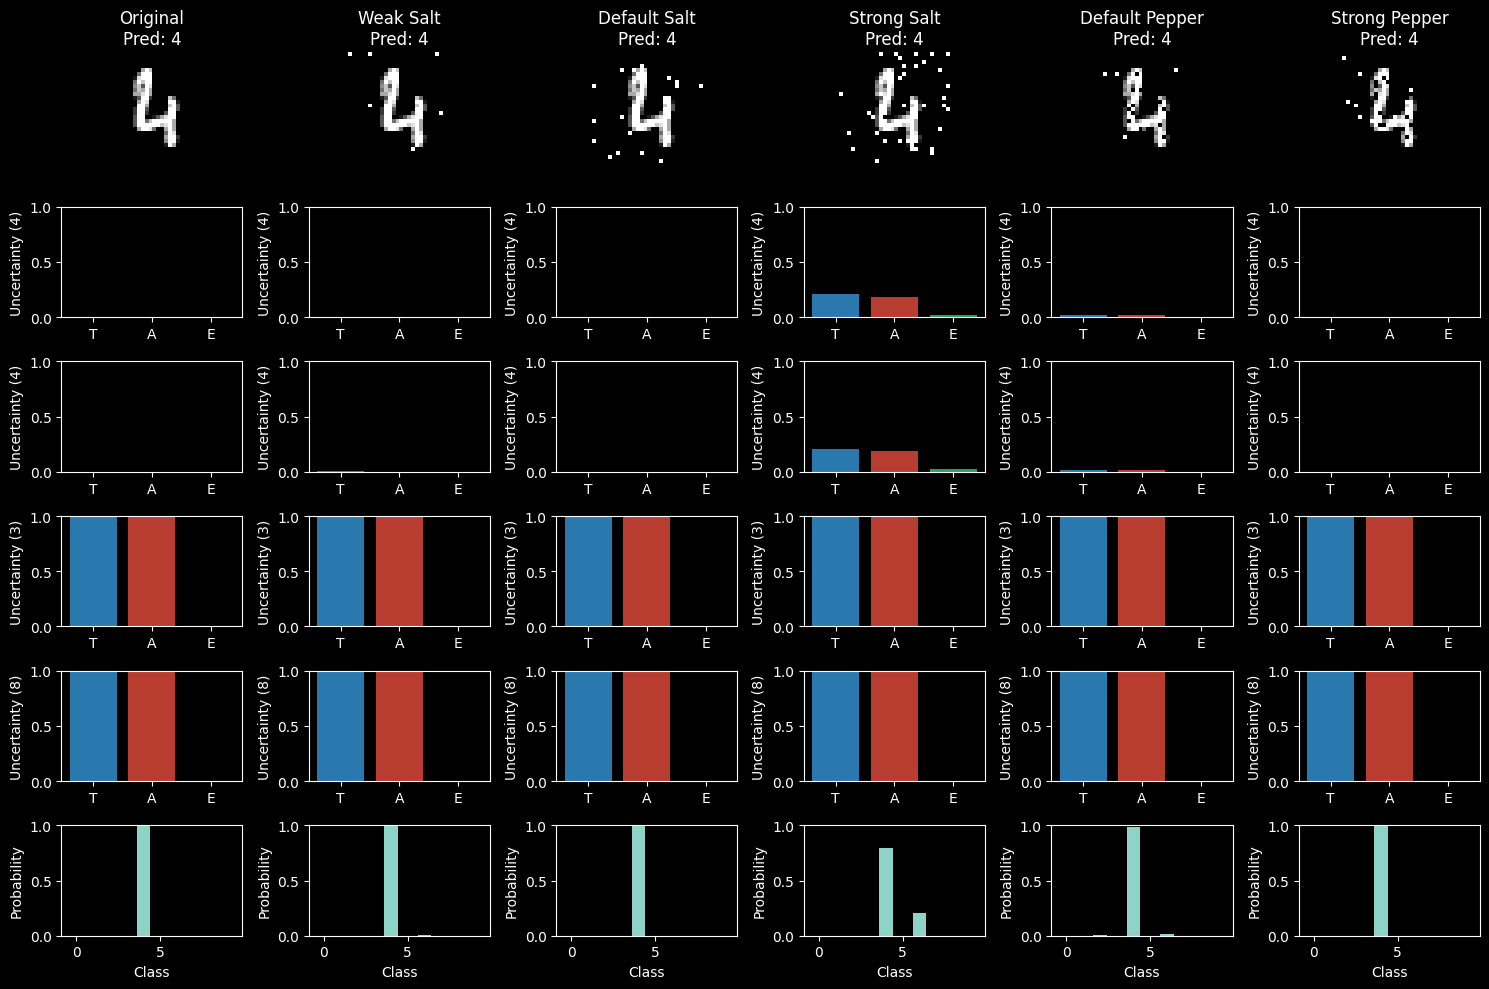

In [71]:
test_on_corruptions(lenet_model, test_loader, device, T=10, batch_idx=222, img_idx=6)


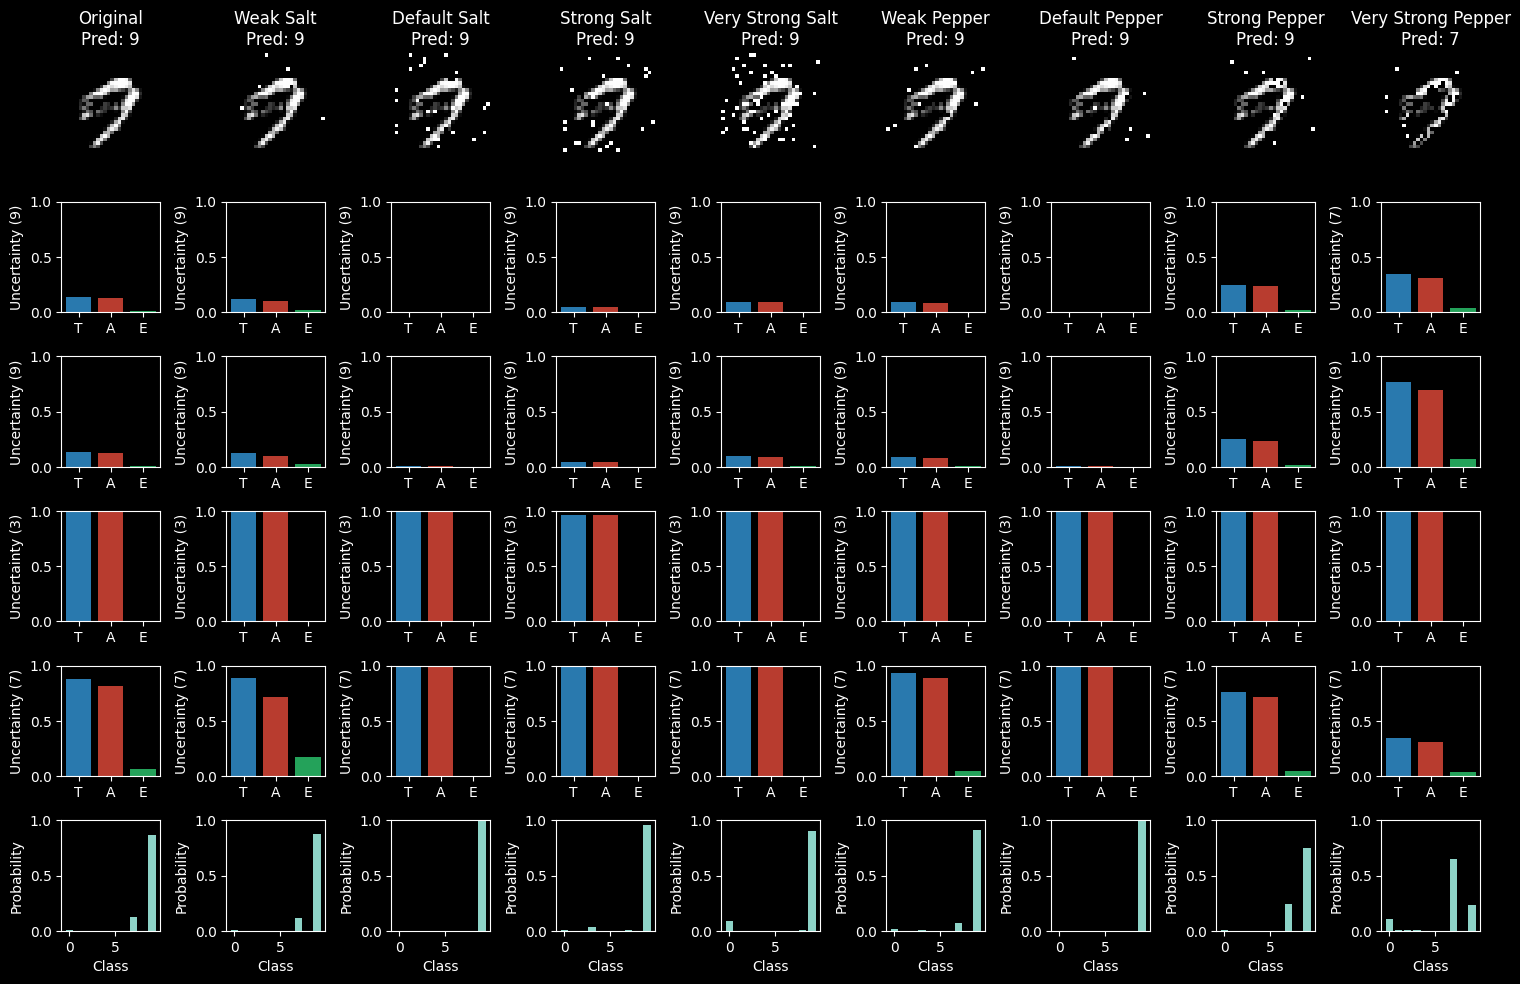

In [79]:
test_on_corruptions(lenet_model, test_loader, device, batch_idx=688, img_idx=10)


## Noise + Salt&Pepper

In [15]:
corruptions = {
    'Original': lambda x: x,
    'Gaussian Noise': lambda x: x + torch.randn_like(x) * 0.3,
    'Salt & Pepper': lambda x: add_salt_pepper(x, 0.1),
    'Combined': lambda x: add_salt_pepper(x + torch.randn_like(x) * 0.3, 0.1),
}


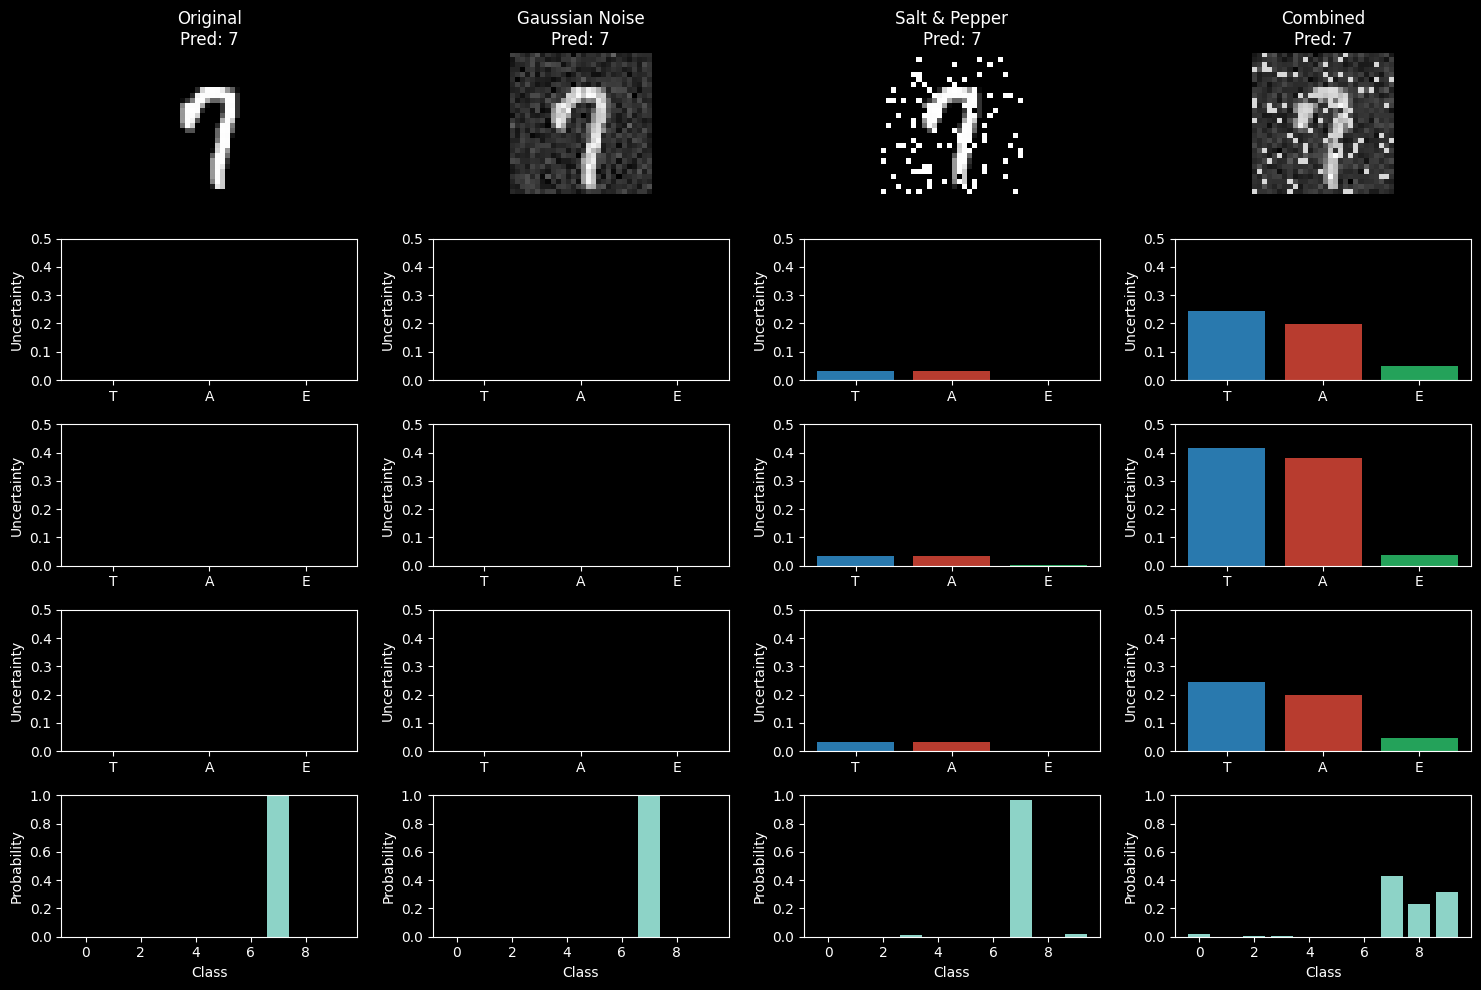

In [19]:
test_on_corruptions(lenet_model, test_loader, device, T=10, batch_idx=406, img_idx=4)

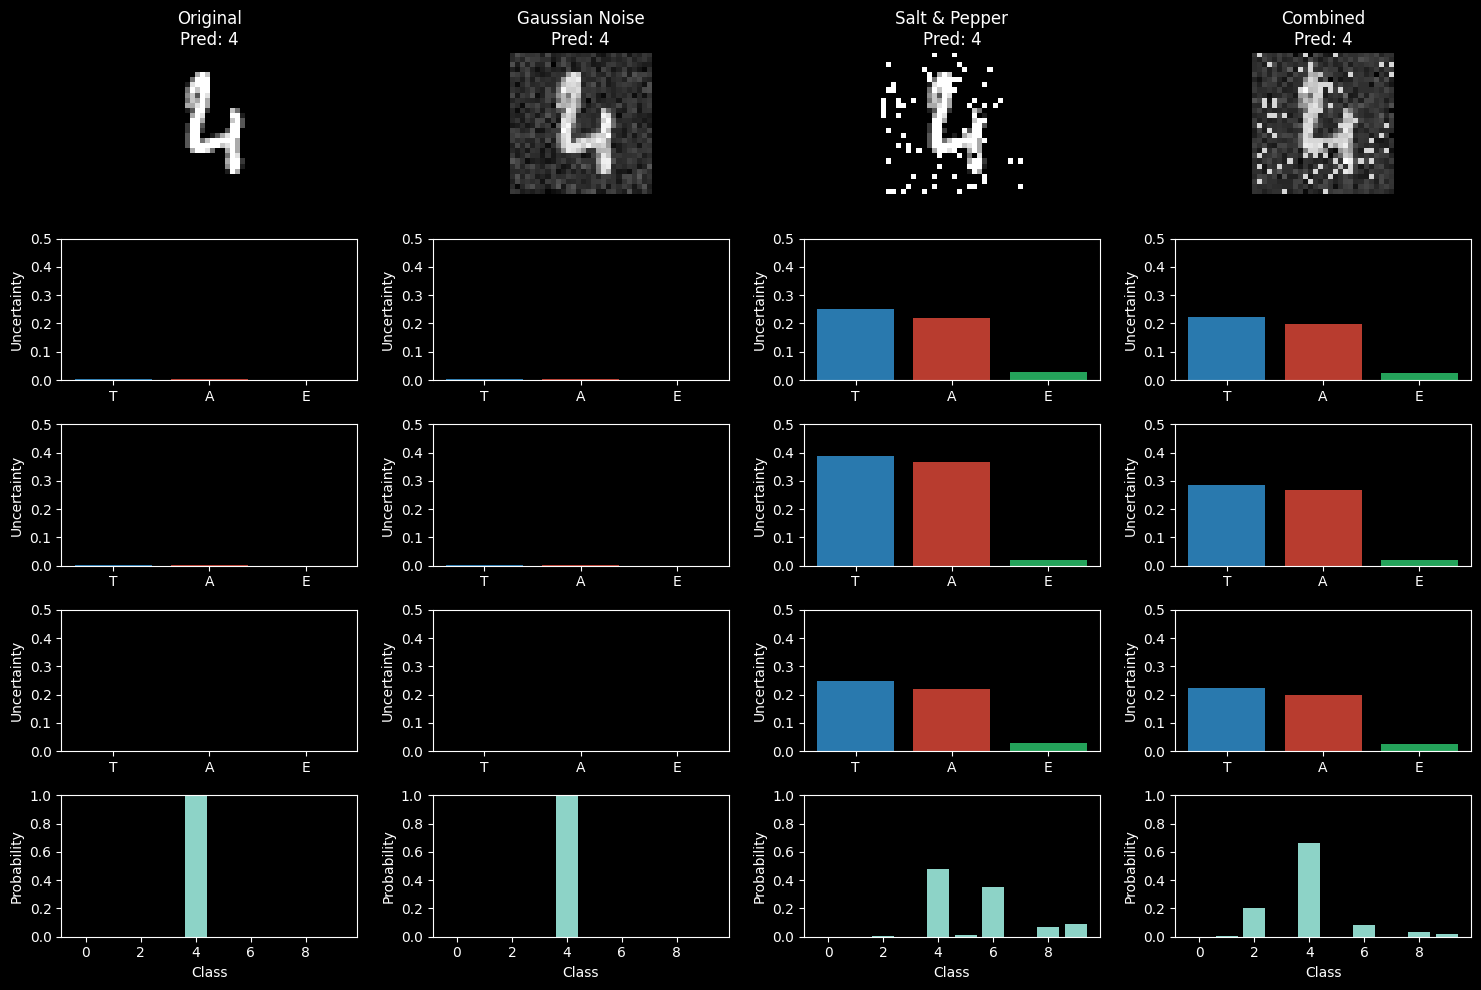

In [30]:
test_on_corruptions(lenet_model, test_loader, device, T=10, batch_idx=222, img_idx=6)

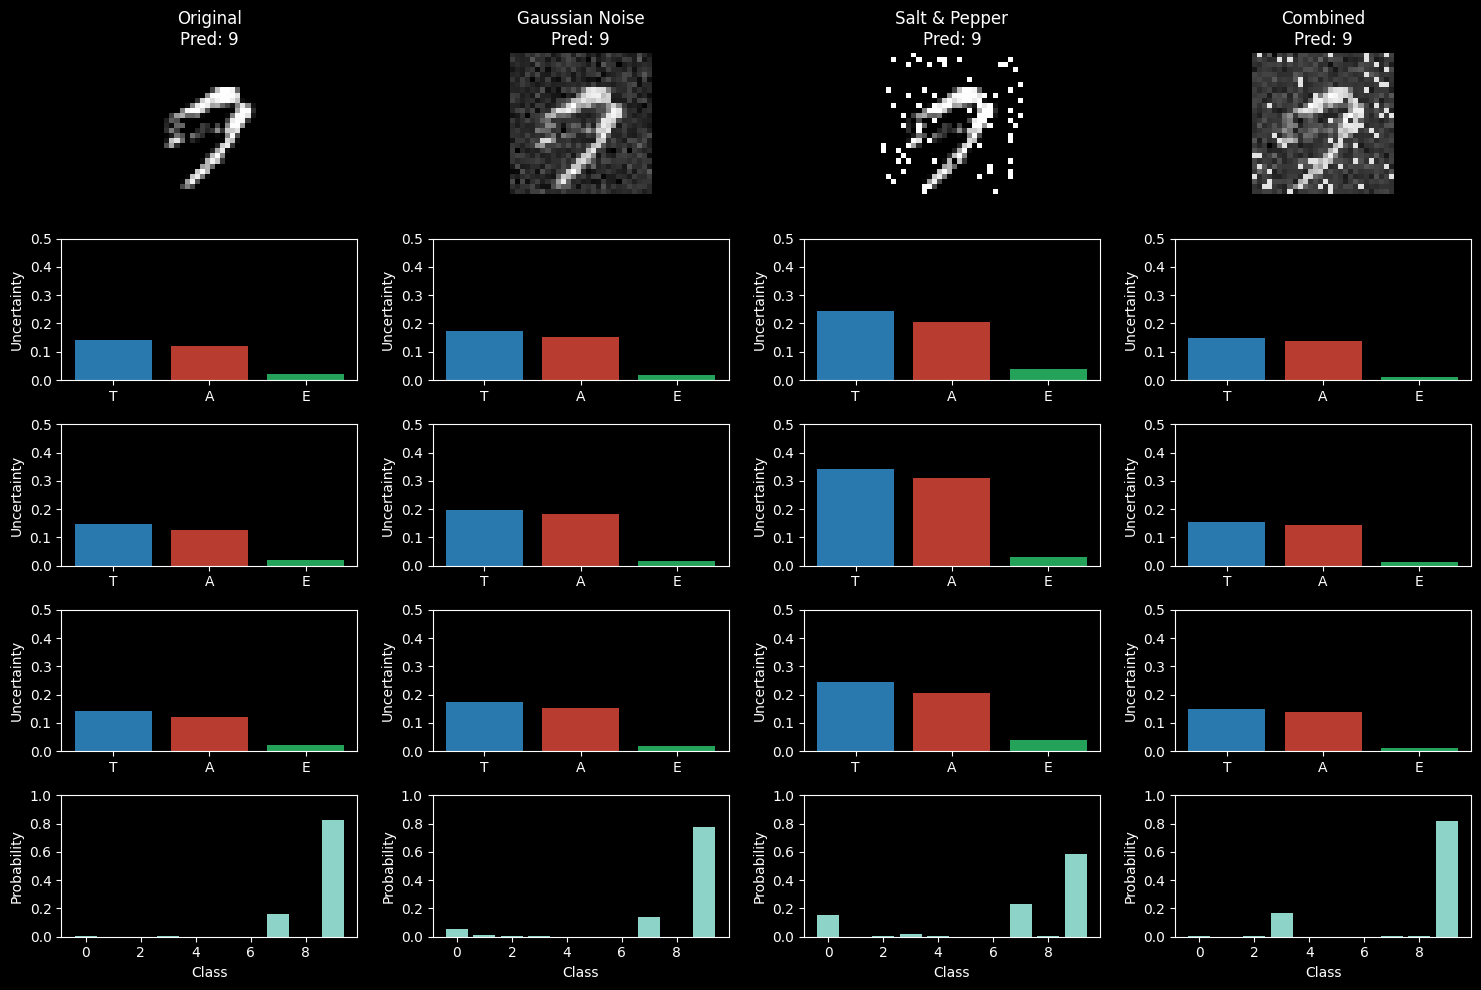

In [31]:
test_on_corruptions(lenet_model, test_loader, device, T=10, batch_idx=688, img_idx=10)

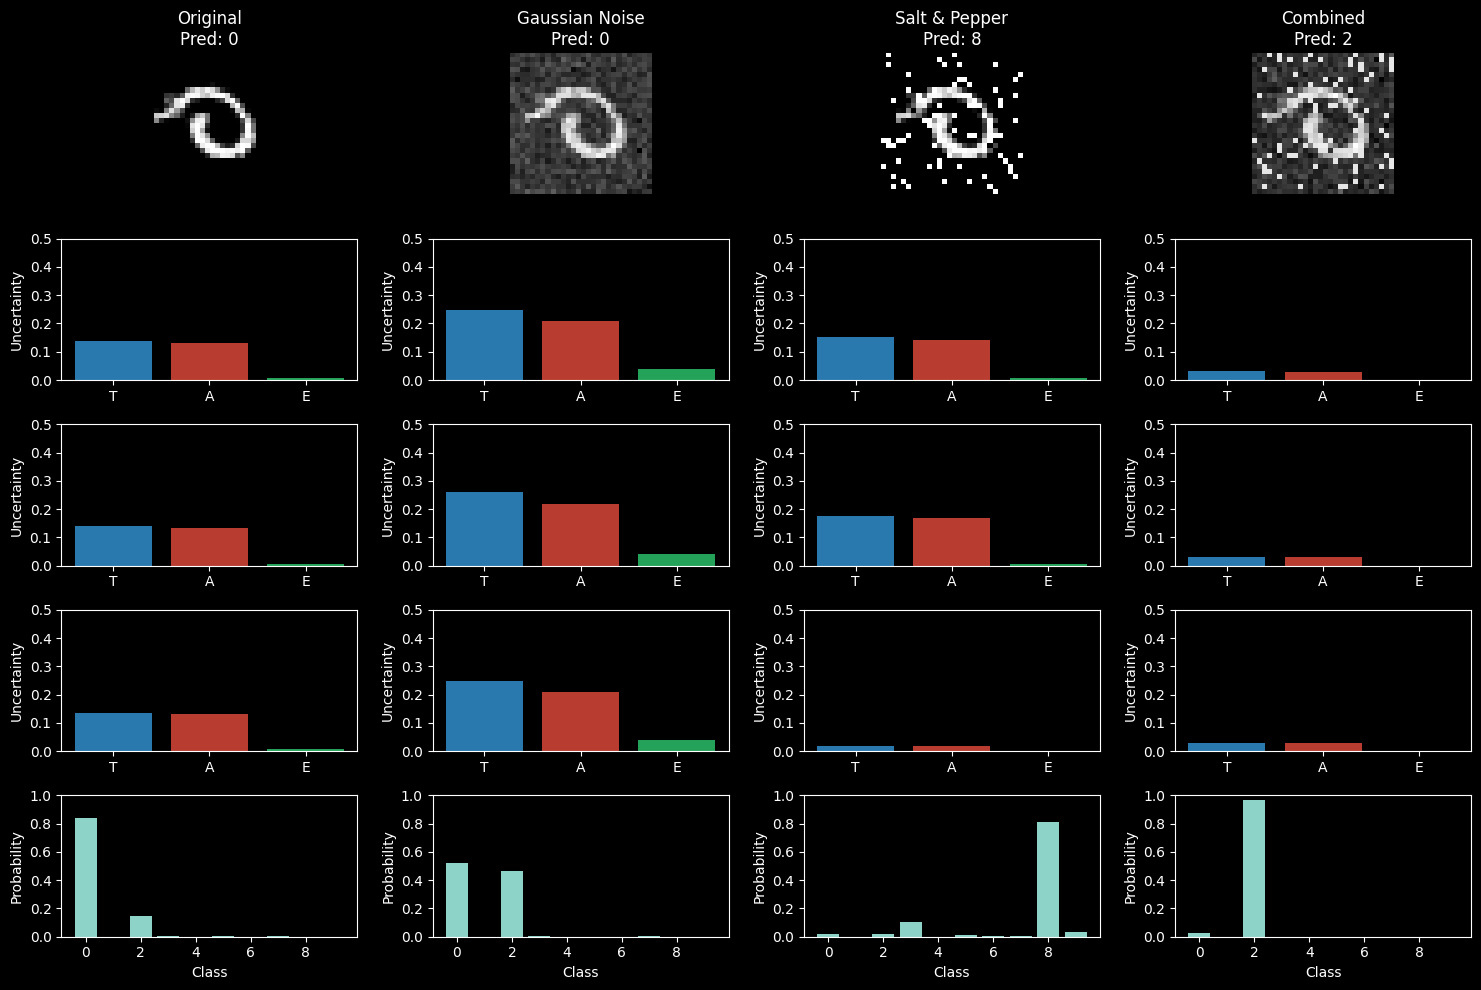

In [32]:
test_on_corruptions(lenet_model, test_loader, device, T=10, batch_idx=290, img_idx=5)